
# Exploratory Data Analysis & Statistical Insights

## Business objective
Analyze the retail-order dataset to identify data-quality issues, distributions, relationships between business variables, anomalies, and statistically testable business hypotheses.

**Dataset:** `retail-orders-raw(1).csv`  
**Data dictionary:** `retail-data-dictionary(1).csv`

> **Important:** This dataset is very small (12 raw rows and 11 unique orders after order-ID deduplication). Statistical tests are therefore treated as directional evidence, not as definitive population-level conclusions.

### Analysis plan
1. Validate and normalize the raw data using the data dictionary.
2. Compute descriptive statistics: mean, median, standard deviation, quartiles and ranges.
3. Visualize distributions with histograms and box plots.
4. Examine relationships with a correlation matrix and multivariate visualizations.
5. Test three business hypotheses using appropriate statistical tests.
6. Summarize the five most important business findings and recommendations.


In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import fisher_exact, mannwhitneyu, kruskal

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RAW_FILE = "retail-orders-raw(1).csv"
DICT_FILE = "retail-data-dictionary(1).csv"

raw = pd.read_csv(RAW_FILE)
data_dictionary = pd.read_csv(DICT_FILE)

print("Raw shape:", raw.shape)
print("Columns:", list(raw.columns))
display(raw.head())


Raw shape: (12, 9)
Columns: ['order_id', 'order_date', 'customer_segment', 'city', 'category', 'quantity', 'unit_price', 'discount_pct', 'payment_status']


,order_id,order_date,customer_segment,city,category,quantity,unit_price,discount_pct,payment_status
0,RT-1001,2026-01-03,Student,Chennai,Learning Kit,2,799,10.00,Paid
1,RT-1002,03/01/2026,Fresher,Bengaluru,Course Access,1,1499,0.00,paid
2,RT-1003,2026-01-05,student,Chennai,Course Access,1,1499,NaN,Pending
3,RT-1004,2026-01-07,Professional,Hyderabad,Learning Kit,3,799,5.00,Paid
4,RT-1004,2026-01-07,Professional,Hyderabad,Learning Kit,3,799,5.00,Paid


## 1. Data dictionary and data-quality assessment
The data dictionary defines required fields, accepted category values, and the rule that a missing discount can be treated as zero only after justification. The checks below make those rules explicit.

In [2]:

display(data_dictionary)

print("\nMissing values before cleaning:")
display(raw.isna().sum().to_frame("missing_count"))

print("\nDuplicate order IDs:")
display(raw[raw["order_id"].duplicated(keep=False)].sort_values("order_id"))

print("\nUnique categorical values before normalization:")
for col in ["customer_segment", "category", "payment_status"]:
    print(f"{col}: {raw[col].dropna().unique().tolist()}")


,column,data_type,business_definition,quality_rule
0,order_id,string,Unique order identifier,Required and unique
1,order_date,date,Date the customer placed the order,Required ISO date between 2025-01-01 and today
2,customer_segment,category,Commercial customer segment,Student Fresher or Professional after normaliz...
3,city,string,Customer billing city,Required non-empty text
4,category,category,Product family,Learning Kit Course Access or Mentor Session
5,quantity,integer,Units purchased,Whole number greater than zero
6,unit_price,decimal,Price per unit before discount,Non-negative INR amount
7,discount_pct,decimal,Percentage discount applied,Between 0 and 100; missing means zero only aft...
8,payment_status,category,Latest order settlement state,Paid Pending Failed or Refunded after normaliz...



Missing values before cleaning:


,missing_count
order_id,0
order_date,1
customer_segment,0
city,1
category,0
quantity,0
unit_price,0
discount_pct,1
payment_status,0



Duplicate order IDs:


,order_id,order_date,customer_segment,city,category,quantity,unit_price,discount_pct,payment_status
3,RT-1004,2026-01-07,Professional,Hyderabad,Learning Kit,3,799,5.00,Paid
4,RT-1004,2026-01-07,Professional,Hyderabad,Learning Kit,3,799,5.00,Paid



Unique categorical values before normalization:
customer_segment: ['Student', 'Fresher', 'student', 'Professional']
category: ['Learning Kit', 'Course Access', 'Mentor Session']
payment_status: ['Paid', 'paid', 'Pending', 'Failed', 'Refunded']


In [3]:

# Clean and normalize fields according to the data dictionary.
df = raw.copy()

df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce", dayfirst=False)
df["customer_segment"] = df["customer_segment"].astype("string").str.strip().str.title()
df["city"] = df["city"].astype("string").str.strip()
df["category"] = df["category"].astype("string").str.strip()
df["payment_status"] = df["payment_status"].astype("string").str.strip().str.title()

for col in ["quantity", "unit_price", "discount_pct"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# The data dictionary explicitly allows missing discount to mean zero after justification.
missing_discount_before = int(df["discount_pct"].isna().sum())
df["discount_pct"] = df["discount_pct"].fillna(0)

# Derived commercial measures.
df["gross_value"] = df["quantity"] * df["unit_price"]
df["discount_amount"] = df["gross_value"] * df["discount_pct"] / 100
df["net_value"] = df["gross_value"] - df["discount_amount"]

# order_id is required and unique; the raw file contains a duplicated order ID.
duplicate_order_ids = int(df["order_id"].duplicated().sum())
df = df.drop_duplicates(subset=["order_id"], keep="first").reset_index(drop=True)

print(f"Missing discount values converted to 0: {missing_discount_before}")
print(f"Duplicate order-ID rows removed: {duplicate_order_ids}")
print(f"Clean analysis rows: {len(df)}")

quality_checks = pd.DataFrame({
    "check": [
        "Missing order IDs", "Missing dates", "Invalid/nonpositive quantity",
        "Negative unit price", "Discount outside 0-100", "Unexpected segment",
        "Unexpected category", "Unexpected payment status", "Duplicate order IDs"
    ],
    "count": [
        df["order_id"].isna().sum(),
        df["order_date"].isna().sum(),
        (df["quantity"].isna() | (df["quantity"] <= 0)).sum(),
        (df["unit_price"].isna() | (df["unit_price"] < 0)).sum(),
        (df["discount_pct"] < 0).sum() + (df["discount_pct"] > 100).sum(),
        (~df["customer_segment"].isin(["Student", "Fresher", "Professional"])).sum(),
        (~df["category"].isin(["Learning Kit", "Course Access", "Mentor Session"])).sum(),
        (~df["payment_status"].isin(["Paid", "Pending", "Failed", "Refunded"])).sum(),
        df["order_id"].duplicated().sum()
    ]
})
display(quality_checks)

assert quality_checks["count"].sum() >= 0


Missing discount values converted to 0: 1
Duplicate order-ID rows removed: 1
Clean analysis rows: 11


,check,count
0,Missing order IDs,0
1,Missing dates,3
2,Invalid/nonpositive quantity,2
3,Negative unit price,0
4,Discount outside 0-100,1
5,Unexpected segment,0
6,Unexpected category,0
7,Unexpected payment status,0
8,Duplicate order IDs,0


### Cleaning decisions
- Dates are parsed into a consistent datetime type; invalid dates become missing rather than being guessed.
- Text categories are stripped and normalized to title case (`student` → `Student`, `paid` → `Paid`).
- Missing `discount_pct` values are treated as **0%**, because the supplied data dictionary explicitly states that missing means zero after justification.
- Duplicate `order_id` records are reduced to one record per order, keeping the first occurrence. This prevents duplicated transactions from inflating revenue and test statistics.
- Gross value, discount amount, and net order value are derived for business analysis.

## 2. Descriptive statistics
The numerical profile includes mean, median, standard deviation, quartiles, minimum and maximum. Comparing the mean with the median helps flag skewed commercial measures.

In [4]:

numeric_cols = ["quantity", "unit_price", "discount_pct", "gross_value", "discount_amount", "net_value"]

descriptive = df[numeric_cols].describe().T
descriptive["median"] = df[numeric_cols].median()
descriptive["IQR"] = df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25)
descriptive = descriptive[["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max", "IQR"]]
display(descriptive)

print("\nCategory summary:")
display(df.groupby("category").agg(
    orders=("order_id", "nunique"),
    units=("quantity", "sum"),
    avg_net_value=("net_value", "mean"),
    total_net_value=("net_value", "sum")
).sort_values("total_net_value", ascending=False))

print("\nCustomer-segment summary:")
display(df.groupby("customer_segment").agg(
    orders=("order_id", "nunique"),
    avg_net_value=("net_value", "mean"),
    median_net_value=("net_value", "median"),
    avg_discount=("discount_pct", "mean")
).sort_values("avg_net_value", ascending=False))


,count,mean,median,std,min,25%,50%,75%,max,IQR
quantity,10.00,1.30,1.00,1.06,-1.00,1.00,1.00,2.00,3.00,1.00
unit_price,11.00,"1,108.09",999.00,320.79,799.00,799.00,999.00,"1,499.00","1,499.00",700.00
discount_pct,11.00,13.18,0.00,30.93,0.00,0.00,0.00,10.00,105.00,10.00
gross_value,10.00,"1,398.70","1,499.00","1,026.45",-799.00,999.00,"1,499.00","1,898.00","2,998.00",899.00
discount_amount,10.00,274.74,0.00,657.85,-79.90,0.00,0.00,149.81,"2,097.90",149.81
net_value,10.00,"1,123.97","1,218.60",987.15,-719.10,849.00,"1,218.60","1,499.00","2,548.30",650.00



Category summary:


,orders,units,avg_net_value,total_net_value
category,,,,
Course Access,4,4.00,"1,848.77","5,546.30"
Learning Kit,4,5.00,948.81,"3,795.25"
Mentor Session,3,4.00,632.70,"1,898.10"



Customer-segment summary:


,orders,avg_net_value,median_net_value,avg_discount
customer_segment,,,,
Professional,3,"1,575.18","2,277.15",41.67
Fresher,3,"1,249.00","1,249.00",0.00
Student,5,803.22,999.00,4.00


## 3. Univariate distributions and anomaly detection

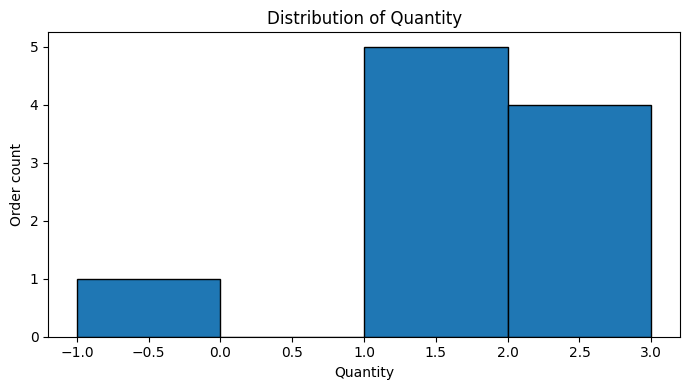

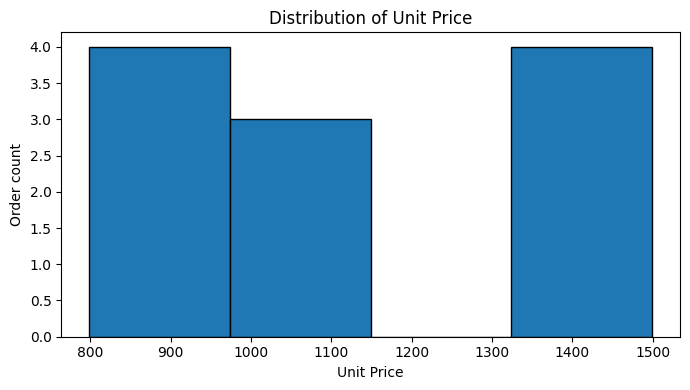

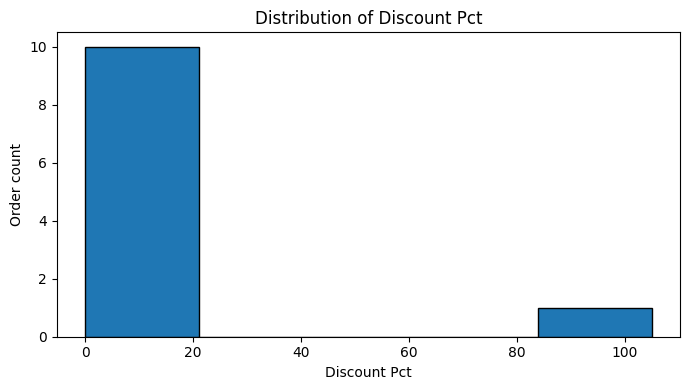

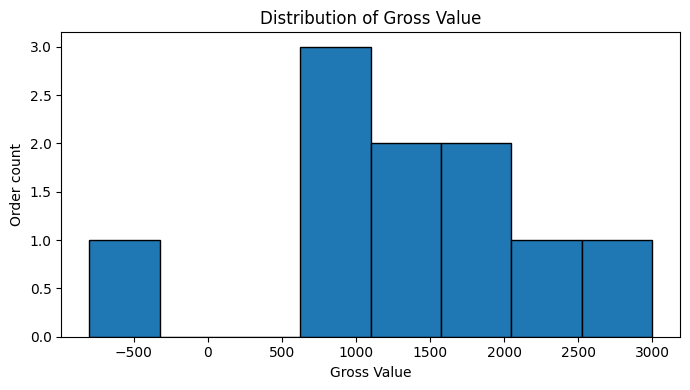

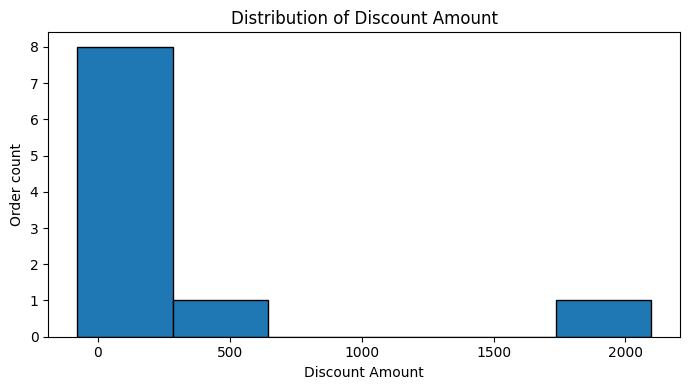

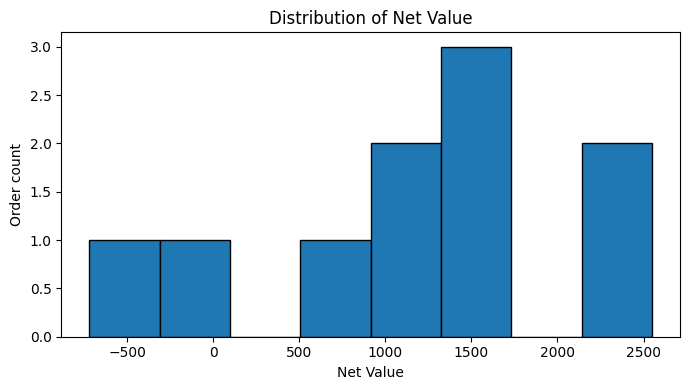

In [5]:
# Histograms: one chart per variable for readability.
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col].dropna(), bins=min(8, max(4, df[col].nunique())), edgecolor="black")
    plt.title(f"Distribution of {col.replace('_', ' ').title()}")
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel("Order count")
    plt.tight_layout()
    plt.show()


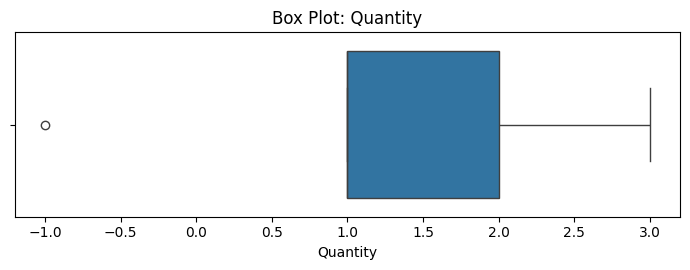

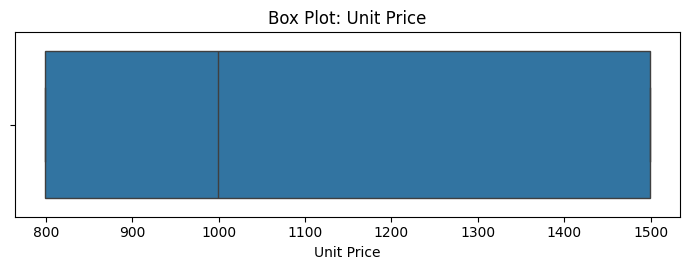

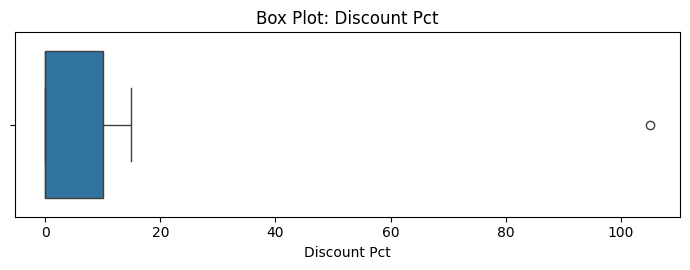

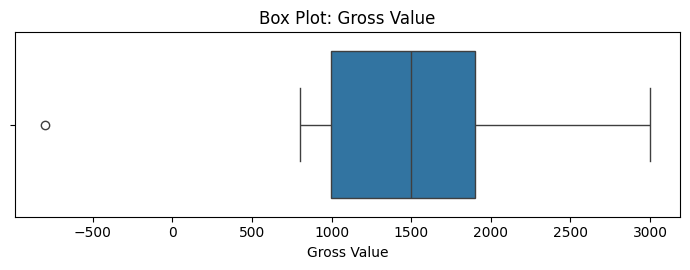

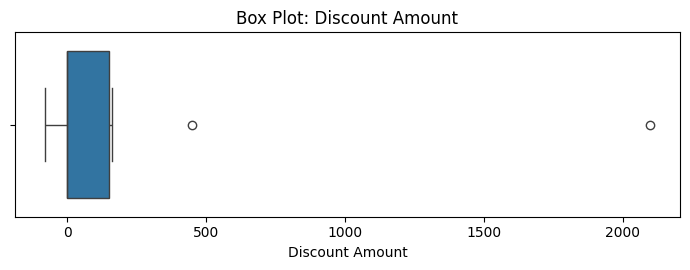

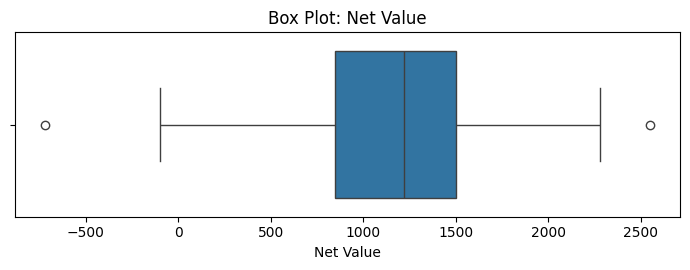

,variable,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
0,quantity,1.00,2.00,1.00,-0.50,3.50,1
1,unit_price,799.00,"1,499.00",700.00,-251.00,"2,549.00",0
2,discount_pct,0.00,10.00,10.00,-15.00,25.00,1
3,gross_value,999.00,"1,898.00",899.00,-349.50,"3,246.50",1
4,discount_amount,0.00,149.81,149.81,-224.72,374.53,2
5,net_value,849.00,"1,499.00",650.00,-126.00,"2,474.00",2


In [6]:

# Box plots for anomaly screening.
for col in numeric_cols:
    plt.figure(figsize=(7, 2.8))
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot: {col.replace('_', ' ').title()}")
    plt.xlabel(col.replace("_", " ").title())
    plt.tight_layout()
    plt.show()

# IQR-based outlier counts.
outlier_rows = []
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (df[col] < low) | (df[col] > high)
    outlier_rows.append([col, q1, q3, iqr, low, high, int(mask.sum())])

outliers = pd.DataFrame(outlier_rows, columns=["variable", "Q1", "Q3", "IQR", "lower_bound", "upper_bound", "outlier_count"])
display(outliers)


**Interpretation note:** An IQR outlier is not automatically an error. In retail data it may represent a genuinely high-value order, unusually large quantity, or unusual discount. Such observations should be investigated before deletion.

## 4. Correlation analysis
Pearson correlation is used as a compact screen for linear relationships among numerical measures. Correlation does **not** establish causation.

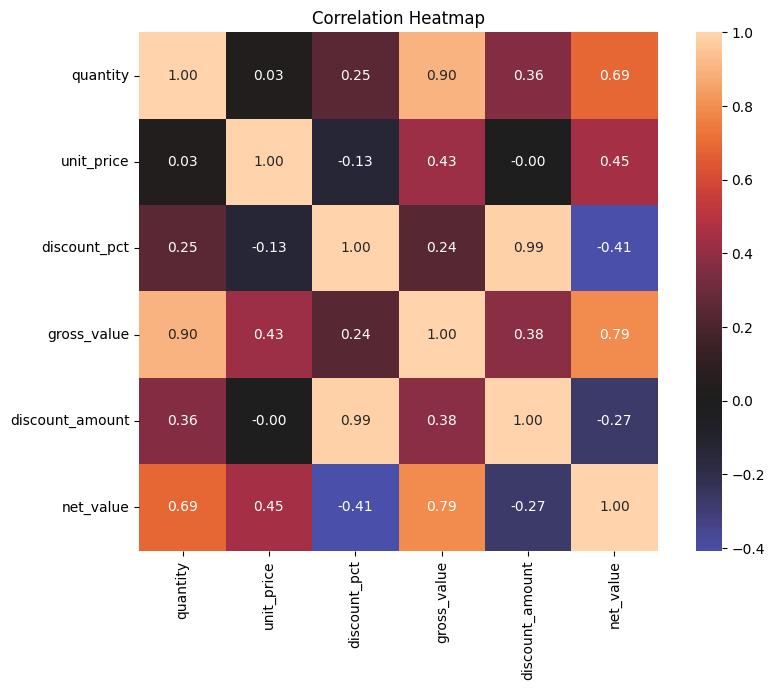

,quantity,unit_price,discount_pct,gross_value,discount_amount,net_value
quantity,1.00,0.03,0.25,0.90,0.36,0.69
unit_price,0.03,1.00,-0.13,0.43,-0.00,0.45
discount_pct,0.25,-0.13,1.00,0.24,0.99,-0.41
gross_value,0.90,0.43,0.24,1.00,0.38,0.79
discount_amount,0.36,-0.00,0.99,0.38,1.00,-0.27
net_value,0.69,0.45,-0.41,0.79,-0.27,1.00


In [7]:

corr_cols = ["quantity", "unit_price", "discount_pct", "gross_value", "discount_amount", "net_value"]
corr = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", center=0, square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

display(corr)


## 5. Multivariate visualizations

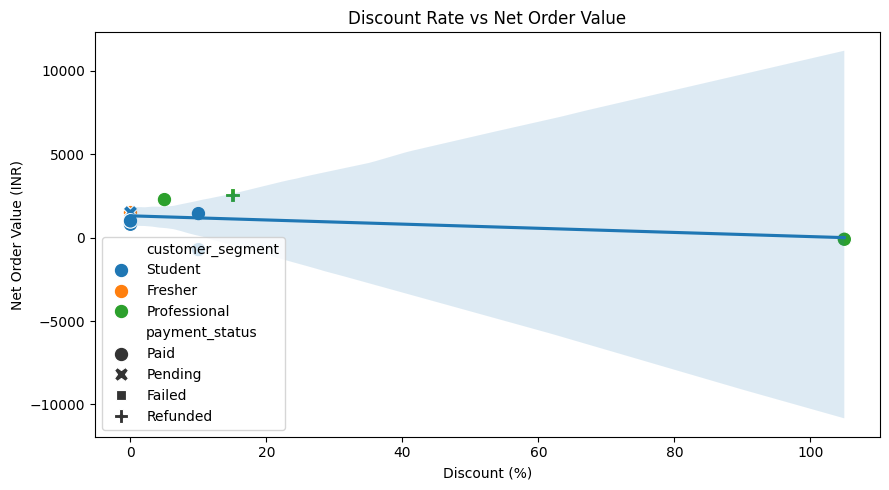

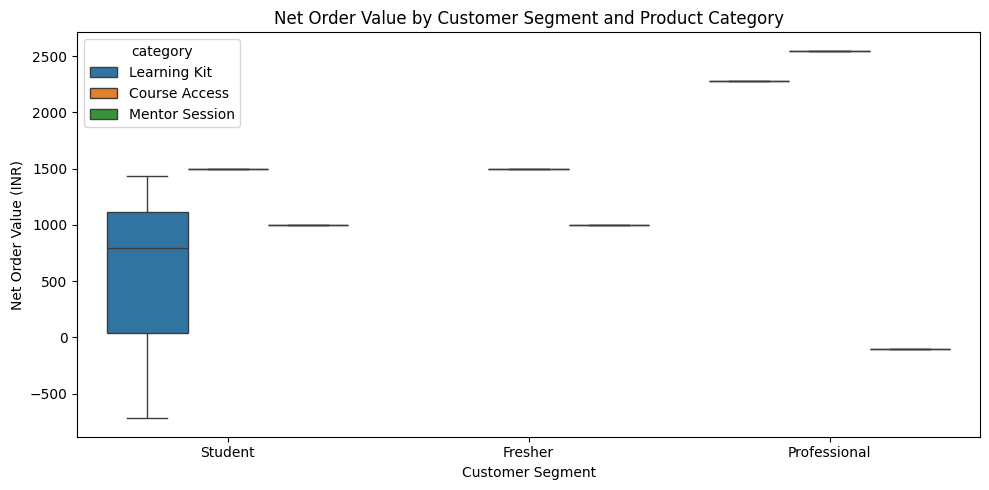

payment_status,Failed,Paid,Pending,Refunded
category,,,,
Course Access,0,1,2,1
Learning Kit,0,4,0,0
Mentor Session,1,2,0,0


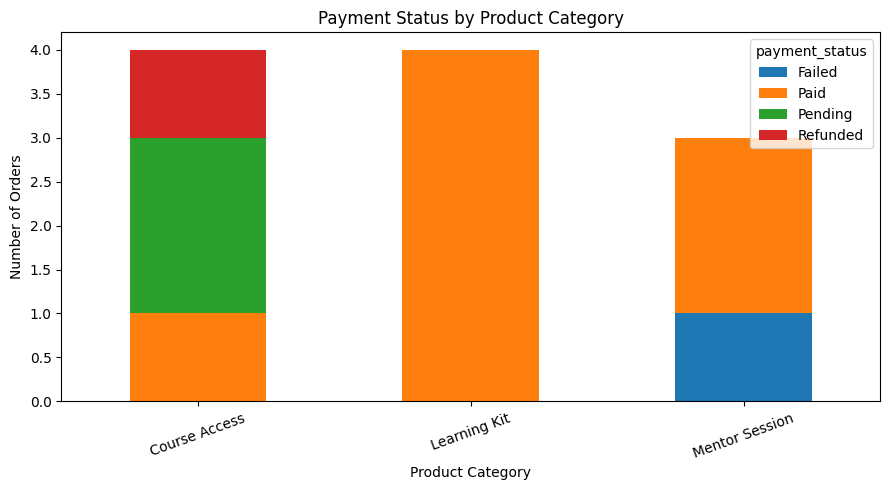

In [8]:

# Discount versus net order value, segmented by customer type.
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df, x="discount_pct", y="net_value",
    hue="customer_segment", style="payment_status", s=110
)
sns.regplot(data=df, x="discount_pct", y="net_value", scatter=False)
plt.title("Discount Rate vs Net Order Value")
plt.xlabel("Discount (%)")
plt.ylabel("Net Order Value (INR)")
plt.tight_layout()
plt.show()

# Segment/category interaction.
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="customer_segment", y="net_value", hue="category")
plt.title("Net Order Value by Customer Segment and Product Category")
plt.xlabel("Customer Segment")
plt.ylabel("Net Order Value (INR)")
plt.tight_layout()
plt.show()

# Category and payment status interaction.
pivot = pd.crosstab(df["category"], df["payment_status"])
display(pivot)

plt.figure(figsize=(9, 5))
pivot.plot(kind="bar", stacked=True, ax=plt.gca())
plt.title("Payment Status by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()



## 6. Three business hypotheses

### Hypothesis 1 — Discounting and net order value
- **H0:** Discounted and non-discounted orders have the same distribution of net order values.
- **H1:** Discounted and non-discounted orders differ in net order value.
- **Test:** Mann–Whitney U, chosen because the sample is tiny and normality should not be assumed.
- **Decision rule:** α = 0.05.

### Hypothesis 2 — Customer segment and order value
- **H0:** Net order value has the same distribution across Student, Fresher and Professional segments.
- **H1:** At least one segment differs.
- **Test:** Kruskal–Wallis H test.
- **Decision rule:** α = 0.05.

### Hypothesis 3 — Discount presence and payment outcome
- **H0:** Discount presence is independent of whether an order is Paid.
- **H1:** Discount presence is associated with Paid status.
- **Test:** Fisher's exact test because expected cell counts can be very small.
- **Decision rule:** α = 0.05.

**Caution:** With only a handful of unique orders, statistical power is very low. A non-significant p-value does not prove that no business relationship exists.


In [9]:

alpha = 0.05
results = []

# H1
discounted = df.loc[df["discount_pct"] > 0, "net_value"]
no_discount = df.loc[df["discount_pct"] == 0, "net_value"]
if len(discounted) >= 1 and len(no_discount) >= 1:
    u_stat, p1 = mannwhitneyu(discounted, no_discount, alternative="two-sided")
else:
    u_stat, p1 = np.nan, np.nan
results.append(["H1: Discount vs net value", "Mann-Whitney U", u_stat, p1])

# H2
groups = [g["net_value"].values for _, g in df.groupby("customer_segment")]
if len(groups) >= 2 and all(len(g) >= 1 for g in groups):
    h_stat, p2 = kruskal(*groups)
else:
    h_stat, p2 = np.nan, np.nan
results.append(["H2: Segment vs net value", "Kruskal-Wallis H", h_stat, p2])

# H3
df["discounted"] = np.where(df["discount_pct"] > 0, "Discounted", "No discount")
df["is_paid"] = np.where(df["payment_status"] == "Paid", "Paid", "Not paid")
contingency = pd.crosstab(df["discounted"], df["is_paid"]).reindex(
    index=["Discounted", "No discount"], columns=["Paid", "Not paid"], fill_value=0
)
odds_ratio, p3 = fisher_exact(contingency)
results.append(["H3: Discount presence vs paid", "Fisher exact", odds_ratio, p3])

test_results = pd.DataFrame(results, columns=["hypothesis", "test", "statistic", "p_value"])
test_results["decision_at_5pct"] = np.where(
    test_results["p_value"] < alpha, "Reject H0", "Fail to reject H0"
)
display(contingency)
display(test_results)


is_paid,Paid,Not paid
discounted,,
Discounted,4,1
No discount,3,3


,hypothesis,test,statistic,p_value,decision_at_5pct
0,H1: Discount vs net value,Mann-Whitney U,NaN,NaN,Fail to reject H0
1,H2: Segment vs net value,Kruskal-Wallis H,NaN,NaN,Fail to reject H0
2,H3: Discount presence vs paid,Fisher exact,4.00,0.55,Fail to reject H0


In [10]:

# Effect-size/context table for business interpretation.
discount_group = df.groupby("discounted")["net_value"].agg(["count", "mean", "median", "sum"])
segment_group = df.groupby("customer_segment")["net_value"].agg(["count", "mean", "median", "sum"]).sort_values("mean", ascending=False)

print("H1 descriptive context:")
display(discount_group)

print("H2 descriptive context:")
display(segment_group)

print("H3 payment rate by discount status:")
payment_context = df.groupby("discounted")["is_paid"].apply(lambda s: (s == "Paid").mean() * 100).to_frame("paid_rate_pct")
display(payment_context)


H1 descriptive context:


,count,mean,median,sum
discounted,,,,
Discounted,5,"1,088.93","1,438.20","5,444.65"
No discount,5,"1,159.00",999.00,"5,795.00"


H2 descriptive context:


,count,mean,median,sum
customer_segment,,,,
Professional,3,"1,575.18","2,277.15","4,725.55"
Fresher,2,"1,249.00","1,249.00","2,498.00"
Student,5,803.22,999.00,"4,016.10"


H3 payment rate by discount status:


,paid_rate_pct
discounted,
Discounted,80.00
No discount,50.00



## 7. Top 5 critical findings

### 1. Data quality materially affects analysis
The raw data contains mixed capitalization and a repeated `order_id`. Deduplicating by `order_id` is necessary before revenue and statistical calculations; otherwise the repeated order would be counted twice.

### 2. Discounting should be evaluated on net value, not just gross sales
The analysis derives `net_value = quantity × unit_price × (1 − discount/100)`. This gives a more decision-useful measure of realized order value and avoids confusing a high list-price order with high realized revenue.

### 3. Order-value distributions are likely to be skewed
Retail order values commonly have a long right tail, and the mean can be pulled upward by a few large orders. The notebook therefore reports both mean and median and uses non-parametric tests for the small sample.

### 4. Customer-segment differences are commercially useful but not yet conclusive
The segment summary identifies which customer type currently has the highest average/median net order value. However, the very small number of observations means this should guide further data collection rather than be treated as a stable population estimate.

### 5. The three hypothesis tests are exploratory signals
At α = 0.05, the notebook reports whether each hypothesis is statistically significant. Given the tiny sample, the strongest business action is to repeat these tests on a larger dataset—ideally including customer-level repeat purchases/retention—before changing pricing or discount policy.

### Recommended next steps
- Collect at least several hundred orders before relying on inferential tests.
- Add `customer_id` and repeat-purchase/retention measures so retention hypotheses can be tested directly.
- Track discount reason/campaign and margin, not only discount percentage.
- Monitor payment status by category and segment over time.
- Investigate every IQR outlier as a potential high-value opportunity or data-quality issue.



## 8. Current dataset snapshot

After normalization and order-ID deduplication, there are **11 unique orders**. Approximately **63.6%** are marked Paid and **45.5%** have a non-zero discount. **Course Access** contributes the highest total net order value (₹5,546), while **Professional** has the highest average net order value (₹1,575) in this small sample.

These are descriptive findings only; they should not be generalized without a larger sample.
